# 1. The data

This notebook loads NAMEM's August biomass from the release of Purevjav et al. (2025) and checks it. It places each monitoring site in its soum and seasonal pasture, adds the soum's weather, and flags likely recording errors. Notebooks 2 to 4 start from the tables it writes.

- **Reads** the release in `data/raw/namem/` (see [data/README.md](../data/README.md)).
- **Writes** `sites.csv`, `site_year.csv` and `flags.csv` to `data/processed/`.
- **Rules** are set in the [research design](../docs/design.md), under "Rules set before the results", and the evidence for them is in the [data checks](../docs/data-checks.md).

Biomass is air-dried and clipped in August, in centners per hectare (1 c/ha = 100 kg/ha).

In [1]:
import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely

from mn_desertification import data, paths, quality, sites
from mn_desertification.rules import FLOOR, HIGH_LIMIT, ZONES

paths.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# At 47°N a degree of longitude is about two-thirds as long as a degree of latitude
MAP_ASPECT = 1 / np.cos(np.radians(47))

## Biomass

One row per site and year, with the site (`gid`), its coordinates, the year and the biomass (`bms`).

In [2]:
biomass = data.read_biomass()
years_per_site = biomass.groupby("gid")["year"].nunique()

print("Rows:", len(biomass))
print("Sites:", biomass["gid"].nunique())
print("Years:", biomass["year"].min(), "to", biomass["year"].max())
print("Sites measured in all 14 years:", (years_per_site == 14).sum())
print("Median biomass (c/ha):", biomass["bms"].median())
print("Duplicate site-years:", biomass.duplicated(["gid", "year"]).sum())

Rows: 18152
Sites: 1488
Years: 2007 to 2020
Sites measured in all 14 years: 773
Median biomass (c/ha): 2.4
Duplicate site-years: 0


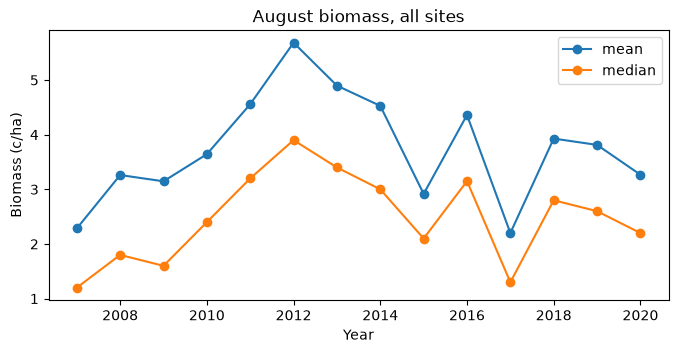

year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
mean,2.28,3.26,3.15,3.64,4.56,5.68,4.9,4.53,2.92,4.36,2.2,3.93,3.81,3.27
median,1.20,1.80,1.60,2.40,3.20,3.90,3.4,3.00,2.10,3.15,1.3,2.80,2.60,2.20


In [3]:
by_year = biomass.groupby("year")["bms"].agg(["mean", "median"])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(by_year.index, by_year["mean"], marker="o", label="mean")
ax.plot(by_year.index, by_year["median"], marker="o", label="median")
ax.set_xlabel("Year")
ax.set_ylabel("Biomass (c/ha)")
ax.set_title("August biomass, all sites")
ax.legend()
plt.show()
by_year.round(2).T

2007 and 2017 are the poorest years and 2012 the best. The mean sits above the median every year, because a few very high values pull it up. That skew is one reason the analysis works with the logarithm of biomass. The other is that a change of 20% then means the same at a desert site and a steppe site.

## Very low and very high values

Values below 0.1 c/ha (10 kg/ha) turn into large negative numbers in logs and could dominate a trend. Values above 30 c/ha (3 t/ha) are rare. Where and when do they occur?

In [4]:
low = biomass[biomass["bms"] < FLOOR]
high = biomass[biomass["bms"] > HIGH_LIMIT]
records = biomass["year"].value_counts().sort_index()

print("Values below 0.1 c/ha:", len(low), "| above 30 c/ha:", len(high))
print("Most common low values:", low["bms"].round(4).value_counts().head(3).to_dict())
print("Most low values at one site:", low["gid"].value_counts().max())
print("2017 values recorded as exactly 0.1:", (biomass.loc[biomass["year"] == 2017, "bms"] == 0.1).sum())

low_count = low["year"].value_counts().reindex(records.index, fill_value=0)
high_count = high["year"].value_counts().reindex(records.index, fill_value=0)
pd.DataFrame({"records": records, "low": low_count, "low %": (low_count / records * 100).round(1), "high": high_count})

Values below 0.1 c/ha: 366 | above 30 c/ha: 22
Most common low values: {0.01: 302, 0.05: 45, 0.001: 17}
Most low values at one site: 4
2017 values recorded as exactly 0.1: 78


,records,low,low %,high
year,,,,
2007,1054,89,8.4,0
2008,1221,67,5.5,0
2009,1259,51,4.1,1
2010,1248,40,3.2,1
2011,1268,1,0.1,1
2012,1307,0,0.0,5
2013,1298,1,0.1,4
2014,1335,17,1.3,5
2015,1237,5,0.4,1


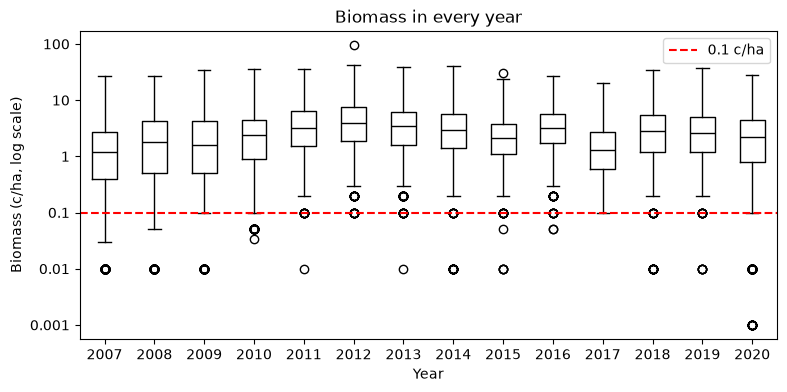

In [5]:
years = sorted(biomass["year"].unique())

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([np.log10(biomass.loc[biomass["year"] == year, "bms"]) for year in years],
           positions=years, medianprops={"color": "black"})
ax.axhline(np.log10(FLOOR), color="red", linestyle="--", label=f"{FLOOR} c/ha")
ax.set_yticks([-3, -2, -1, 0, 1, 2], labels=["0.001", "0.01", "0.1", "1", "10", "100"])
ax.set_xlabel("Year")
ax.set_ylabel("Biomass (c/ha, log scale)")
ax.set_title("Biomass in every year")
ax.legend()
plt.show()

- **Low values belong to the early years.** 247 of the 366 values below 0.1 c/ha fall in 2007–2010, 3 to 8% of each year's records. From 2011 to 2019 about 1% or less of each year's records are that low. In 2017, the poorest year, none are: its near-empty sites were recorded as exactly 0.1, the smallest step of the scale.
- **They are stand-ins for zero.** 364 of the 366 are exactly 0.01, 0.05 or 0.001. Biomass is otherwise recorded in steps of 0.1 c/ha.
- **No site has more than four of them,** so they are not a few bare sites.
- **2020 has 73,** clustered in the south-central Gobi (see the weather section below).
- **High values are spread out.** The 22 values above 30 c/ha fall in 2009–2019.

These findings set two rules of the design. The main period is 2011–2020, the years of NAMEM's standard method. Values below 0.1 c/ha are raised to 0.1 before taking logs, which puts the stand-ins level with near-empty sites.

## Sites and soums

Each site needs its soum, to get the soum's weather, ecological zone and herds. The soum map has one outline per soum. Some provincial centres are small soums inside a larger soum whose outline has no hole for them. Going from the largest soum to the smallest lets the small soum win.

In [6]:
site_list = biomass[["gid", "lon", "lat"]].drop_duplicates("gid")
soum_outlines = data.read_soum_outlines()
placed = sites.assign_soums(site_list, soum_outlines)

print("Soum outlines:", len(soum_outlines), "| valid:", sum(p.is_valid for p in soum_outlines.values()))
print("Outlines containing a site:", placed["n_hits"].value_counts().sort_index().to_dict())

site_info = placed.merge(data.read_soum_names(), left_on="soum_id", right_on="_ID", how="left")
site_info = site_info.drop(columns=["_ID"])
print("Soums with a site:", site_info["asid"].nunique(), "| aimags:", site_info["aimag_eng"].nunique())

# The sites inside two outlines, each now in the smaller soum
site_info.loc[site_info["n_hits"] > 1, ["gid", "aimag_eng", "soum_eng", "soum_mng"]]

Soum outlines: 339 | valid: 339
Outlines containing a site: {1: 1481, 2: 7}
Soums with a site: 329 | aimags: 22


,gid,aimag_eng,soum_eng,soum_mng
792,913,Sukhbaatar,Baruun-Urt,Баруун-Урт
903,1070,Tuv,Zuunmod,Зуунмод
904,1071,Tuv,Zuunmod,Зуунмод
906,1073,Tuv,Zuunmod,Зуунмод
1322,743,Uvurkhangai,Arvaikheer,Арвайхээр
1442,864,Umnugovi,Dalanzadgad,Даланзадгад
1443,863,Umnugovi,Dalanzadgad,Даланзадгад


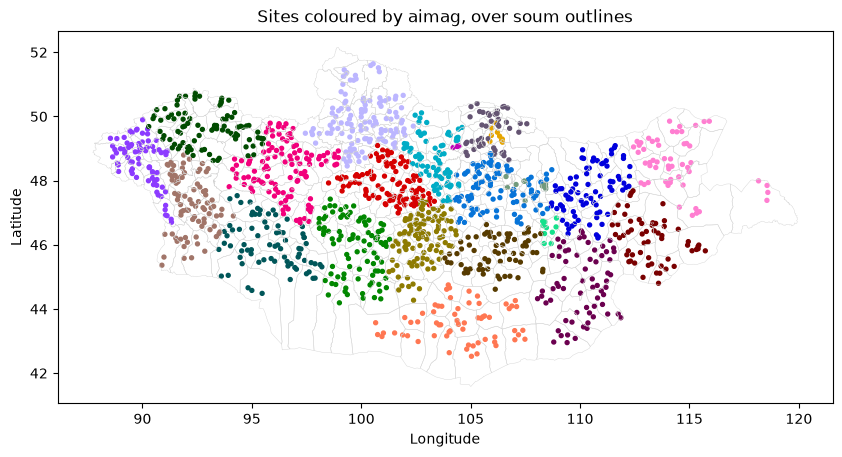

In [7]:
aimag_names = sorted(site_info["aimag_eng"].unique())
colour_of = dict(zip(aimag_names, cc.glasbey_dark))   # one colour per aimag

fig, ax = plt.subplots(figsize=(10, 6))
for outline in soum_outlines.values():
    ax.plot(*outline.exterior.xy, color="lightgrey", linewidth=0.3)
ax.scatter(site_info["lon"], site_info["lat"], c=site_info["aimag_eng"].map(colour_of), s=8)
ax.set_aspect(MAP_ASPECT)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sites coloured by aimag, over soum outlines")
plt.show()

1,481 sites lie inside one outline and 7 inside two, in the provincial centres Baruun-Urt, Zuunmod, Arvaikheer and Dalanzadgad. No site lies outside every outline. On the map each aimag forms a solid patch of one colour, so no site sits in the wrong place. 329 soums in 22 aimags, counting Ulaanbaatar, have at least one site.

## Seasonal pastures

The release's seasonal pasture map comes from the land agency's 2021 State Land Report (Purevjav et al. 2025, supplement p. S3). Winter-spring ranges are used December to May, and summer-fall ranges June to November. Notebook 4 compares the two.

Each of the map's 16 areas is drawn as many outlines, and many outlines are holes cut out of larger ones. A site inside an outline and also inside a hole in it lies within two outlines but is not in the area. So a site is in an area when it lies within an odd number of the area's outlines. Reading the 5.3 GB map takes about 15 seconds.

In [8]:
outlines, area_of_outline, area_names = data.read_pasture_outlines()
counts = sites.outlines_around(site_info, outlines, area_of_outline)

# In the map, as in shapefiles, outer outlines run clockwise and holes counterclockwise.
holes = shapely.is_ccw(shapely.get_exterior_ring(outlines))
print("Outlines in the map:", len(outlines), "| holes:", holes.sum())
print("Outlines around a site, per area:", counts.value_counts().to_dict())
print("The odd-count rule agrees with outline direction:", sites.agrees_with_direction(site_info, outlines, area_of_outline))
del outlines, holes   # frees about a gigabyte

site_info["pasture"] = sites.pasture_type(site_info["gid"], counts, area_names)
site_info["pasture"].value_counts()

Outlines in the map: 251865 | holes: 184876
Outlines around a site, per area: {1: 1253, 2: 8}


The odd-count rule agrees with outline direction: True


pasture
winter-spring    755
summer-fall      498
outside map      235
Name: count, dtype: int64

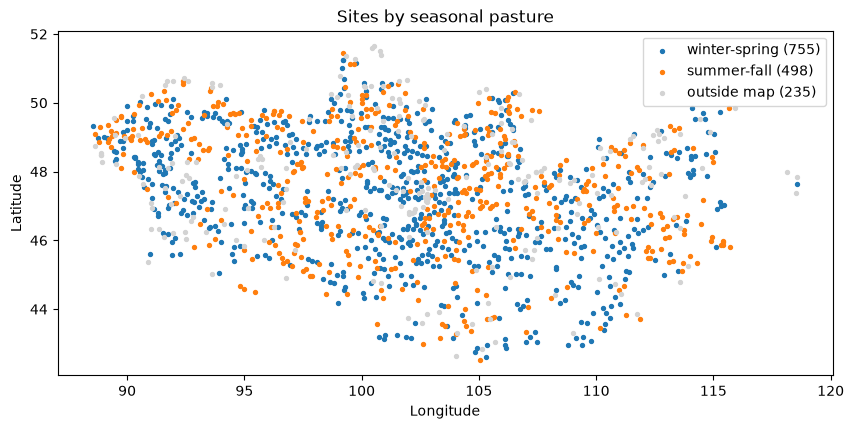

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for kind, colour in [("winter-spring", "tab:blue"), ("summer-fall", "tab:orange"), ("outside map", "lightgrey")]:
    chosen = site_info[site_info["pasture"] == kind]
    ax.scatter(chosen["lon"], chosen["lat"], s=8, color=colour, label=f"{kind} ({len(chosen)})")
ax.set_aspect(MAP_ASPECT)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sites by seasonal pasture")
ax.legend()
plt.show()

In [10]:
# The 16 areas of the map, with the number of sites in each
areas = data.read_pasture_areas()
areas["sites"] = areas["area"].map(counts[counts % 2 == 1].reset_index()["area"].value_counts()).fillna(0).astype(int)
areas

,area,range,type,name_eng,sites
0,1,"Winter-Spring Grazing Range, WGR",Өвөл-хаврын,winter-spring,281
1,2,"Winter-Spring Grazing Range, WGR",Өвөл-хаврын,winter-spring,141
2,3,"Winter-Spring Grazing Range, WGR",Өвөл-хаврын,winter-spring,89
3,4,"Winter-Spring Grazing Range, WGR",Өвөл-хаврын,winter-spring,42
4,5,"Winter-Spring Grazing Range, WGR",Өвөл-хаврын,winter-spring,88
5,6,"Winter-Spring Grazing Range, WGR",Өвөл-хаврын,winter-spring,108
6,7,"Summer-Fall Grazing Range, SGR",Зун-намрын,summer-fall,168
7,8,"Summer-Fall Grazing Range, SGR",Зун-намрын,summer-fall,89
8,9,"Summer-Fall Grazing Range, SGR",Зун-намрын,summer-fall,63
9,10,"Summer-Fall Grazing Range, SGR",Зун-намрын,summer-fall,53


- **The map.** 184,876 of its 251,865 outlines are holes. The odd-count rule and outline direction place every site the same way. The 8 site-area pairs with two outlines are sites in a hole, which count as outside that area.
- **Winter-spring ranges.** 755 sites lie on them, 6 of these in the areas for winter and spring camps.
- **Summer-fall ranges.** 498 sites lie on them.
- **Outside the mapped pasture.** 235 sites, probably on land the map treats as non-pasture, which the supplement says includes protected areas and uninhabitable desert.
- **The rest.** No site is in the reserve or unused areas, and none is in two areas. Both pasture types spread across the whole country.

## Weather

The release gives weather on each soum's summer grazing range, from ERA5-Land. Growing-season rain is spring (March–May) and summer (June–August) rain added together. The release's year runs from 1 September to 31 August and is named after the year in which it ends, so the summer of year 2017 is the summer of the August 2017 clipping.

In [11]:
weather = data.read_soum_weather()
site_info["zone"] = site_info["asid"].map(weather.groupby("asid")["zone"].first())

rain_by_year = (weather[weather["year"].between(2007, 2020)]
                .groupby("year")[["rain_spring", "rain_summer", "rain_growing", "temp_summer"]]
                .mean()
                .astype(float))   # temperature is stored as 32-bit numbers; show it rounded
rain_by_year.round(1)

,rain_spring,rain_summer,rain_growing,temp_summer
year,,,,
2007,56.8,158.0,214.8,18.2
2008,53.6,166.4,220.0,17.2
2009,49.2,148.0,197.3,16.2
2010,64.9,146.7,211.5,17.5
2011,53.8,159.7,213.5,17.2
2012,48.1,189.3,237.3,16.4
2013,52.2,172.6,224.9,16.1
2014,68.9,137.5,206.4,16.5
2015,51.0,157.8,208.8,17.4


In [12]:
# If the years line up, biomass should follow the same year's rain, not the previous or next year's.
rain_mean = weather.groupby("year")["rain_growing"].mean()
biomass_mean = biomass.groupby("year")["bms"].mean()
for label, shift in [("the same year", 0), ("the previous year", 1), ("the next year", -1)]:
    rain = rain_mean.reindex(biomass_mean.index - shift).to_numpy()
    print(f"Biomass against rain in {label}: r = {np.corrcoef(rain, biomass_mean.to_numpy())[0, 1]:.2f}")

Biomass against rain in the same year: r = 0.54
Biomass against rain in the previous year: r = -0.06
Biomass against rain in the next year: r = -0.27


Biomass follows the same year's rain (r = 0.54), so the years line up. 2017 had the least growing-season rain and the least biomass. 2007–2010 had ordinary rain but low biomass, so rain does not explain the early low values.

In [13]:
# One row per site and year, with the soum's rain. Summer temperature is added from the
# release when it is needed, so that it keeps the precision it is stored with.
site_year = (biomass
             .merge(site_info[["gid", "asid", "aimag_eng", "soum_eng"]], on="gid", how="left")
             .merge(weather.drop(columns="temp_summer"), on=["asid", "year"], how="left"))
site_year = quality.add_rain_percent(site_year, weather)

print("Site-years:", len(site_year))
print("Without rain:", site_year["rain_growing"].isna().sum(), "| without zone:", site_year["zone"].isna().sum())
site_info.drop_duplicates("gid")["zone"].value_counts().reindex(ZONES)

Site-years: 18152
Without rain: 0 | without zone: 0


zone
Desert zone                113
Semi desert steppe zone    325
Steppe zone                627
Forest steppe zone         374
Mountain taiga belt         49
Name: count, dtype: int64

### The 2020 cluster

The low values of 2020 cluster in the south-central Gobi. Rain as a percent of each soum's 2011–2020 normal shows why.

In [14]:
in_2020 = site_year[site_year["year"] == 2020]
is_low = in_2020["bms"] < FLOOR
comparison = pd.DataFrame({
    "2020, low values": in_2020.loc[is_low, "rain_pct"].describe(),
    "2020, other records": in_2020.loc[~is_low, "rain_pct"].describe(),
    "2017, all records": site_year.loc[site_year["year"] == 2017, "rain_pct"].describe(),
}).round()
print(in_2020.loc[is_low, "aimag_eng"].value_counts().to_dict())
comparison

{'Bayankhongor': 36, 'Umnugovi': 15, 'Uvurkhangai': 13, 'Dundgovi': 5, 'Govi-Altai': 2, 'Dornod': 1, 'Sukhbaatar': 1}


,"2020, low values","2020, other records","2017, all records"
count,73.0,1323.0,1386.0
mean,56.0,109.0,80.0
std,21.0,30.0,11.0
min,33.0,33.0,55.0
25%,45.0,92.0,73.0
50%,48.0,112.0,79.0
75%,57.0,132.0,86.0
max,149.0,177.0,128.0


The 2020 low values sit where growing-season rain was about half of normal (median 48%), while the other sites that year got more than normal (112%). In the 2017 drought the whole country got about 79%. A severe dry year in the south-central Gobi explains the cluster, so by the design's rule these values stay, under the floor. Notebook 4 shows that the weather model under-predicts how hard this drought hit.

### Biomass by zone and year

Each site against its own average, in logs with the floor, averaged by zone. +0.3 is about twice a site's usual biomass and −0.3 about half.

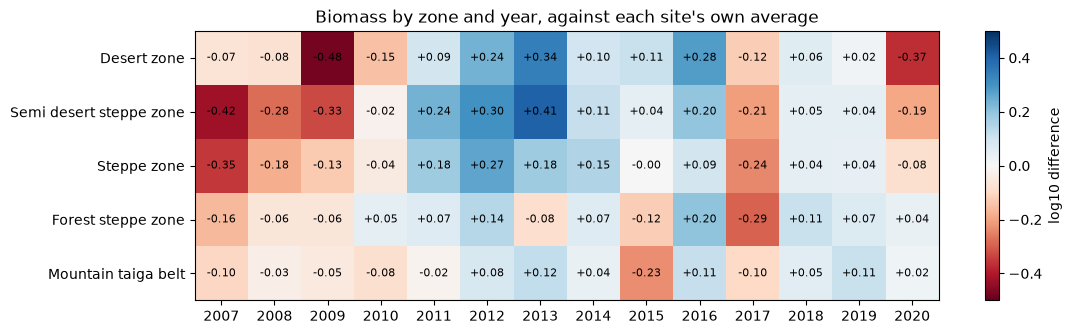

In [15]:
site_year["log_bms"] = quality.floored_log(site_year["bms"])
grid = site_year.pivot(index="gid", columns="year", values="log_bms")
anomaly = grid.sub(grid.mean(axis=1), axis=0)
zone_year = anomaly.groupby(site_info.set_index("gid")["zone"]).mean().reindex(ZONES)
site_year = site_year.drop(columns="log_bms")

fig, ax = plt.subplots(figsize=(12, 3.5))
image = ax.imshow(zone_year, cmap="RdBu", vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_xticks(range(len(zone_year.columns)), labels=zone_year.columns)
ax.set_yticks(range(len(ZONES)), labels=ZONES)
for i in range(zone_year.shape[0]):
    for j in range(zone_year.shape[1]):
        ax.text(j, i, f"{zone_year.iloc[i, j]:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="log10 difference")
ax.set_title("Biomass by zone and year, against each site's own average")
plt.show()

Most zones sit below their average in 2007–2010 and above it in 2011–2014. 2017 is low everywhere, and 2020 is low in the desert and semi-desert steppe.

## Likely recording errors

A value is flagged only on several pieces of evidence, and the raw data stay unchanged ([design](../docs/design.md), "Recording errors"):

- A **lone spike** is more than 10 times what the site's usual level and its zone's year predict, in a soum-year with less than 120% of normal rain, with no other site in the soum above 3 times its expected value.
- A value **off the scale** is more than twice any other value in the record.

A first rule, which dropped any value more than 10 times the median of the site's other years, would have removed 77 values, mostly real peaks of the good years 2012 and 2013. It was replaced before any trend was computed.

In [16]:
flags = quality.flag_recording_errors(site_year)
flags.merge(site_info[["gid", "lat", "lon", "aimag_eng", "soum_eng"]], on="gid")

,gid,year,bms,flag,lat,lon,aimag_eng,soum_eng
0,28,2012,96.00,off the scale,48.006583,102.377333,Arkhangai,Ulziit
1,1289,2013,26.50,lone spike,48.320556,91.360222,Khovd,Erdeneburen
2,759,2013,39.58,lone spike,45.966190,103.207000,Uvurkhangai,Bayangol


Site 28 in 2012, at 96 c/ha, is more than twice the next-largest value in the record (42 c/ha). Sites 1289 and 759 in 2013 are lone spikes. The three values are left out of the main analysis and put back in a robustness check in notebook 3. They should be confirmed against NAMEM's original records.

## Save

In [17]:
outputs = {
    "sites.csv": site_info[["gid", "lon", "lat", "soum_id", "asid", "aimag_eng", "soum_eng",
                            "aimag_mng", "soum_mng", "zone", "pasture"]],
    "site_year.csv": site_year,
    "flags.csv": flags,
}
for name, table in outputs.items():
    table.to_csv(paths.PROCESSED_DIR / name, index=False)
    print(f"Saved {len(table)} rows to data/processed/{name}")

Saved 1488 rows to data/processed/sites.csv
Saved 18152 rows to data/processed/site_year.csv
Saved 3 rows to data/processed/flags.csv
